In [1]:
import numpy as np
import matplotlib.pyplot as plt
from helpers import compute_N
from tqdm import tqdm
from helpers import *
import os

In [2]:
# Set the constants
T0 = 1.0                      # initial temperature
Tbar = 1.0                    # background temperature
Tw = 1.0                      # wall temperature
m = 1.0                       # mass
k = 1.0                       # Boltzmann constant

# Knudsen and Mach numbers
Kn = 0.1
Ma = 0.316

# Derived parameters
Uw = Ma * np.sqrt(k * Tw / m)          
tau = 2 * Kn / np.sqrt(np.pi / 2)     

# Domain
L = 1.0
Nc = 10
dx = L / Nc                            # = 0.02

# Particles
Np = 50000                            # 5000 per cell

# Timestep from paper equation (100)
dt = 0.5 * L / (Nc * np.sqrt(k * Tw / m))  # = 0.01

# Simulation time
t_end = 5.0                            # 100 tau relaxation times
t = 0
Nsteps = int(t_end // dt) + 1

# NW bandwidth
h = 4 * dx                             # = 0.04

# Grid
x_grid = np.linspace(-L/2 + dx/2, L/2 - dx/2, Nc)

correlated_process = True

In [3]:
def compute_cell_moments(M, cell_index, Nc, Mbar=None, Ubar=None): 
    U = np.zeros((Nc, 3))
    T = np.zeros(Nc)

    if Mbar is not None:
        if Ubar is None:
            raise ValueError("If Mbar is provided, Ubar must also be provided")
        M_corrected = M - Mbar + Ubar[cell_index]
    else:
        M_corrected = M

    for c in range(Nc):
        mask = cell_index == c
        if mask.any():
            V_cell = M_corrected[mask]

            # Mean velocity
            U[c] = V_cell.mean(axis=0)

            # Temperature
            T[c] = (m / (3 * k)) * ((V_cell - U[c])**2).sum(axis=1).mean()
            
    return U, T
'''
def compute_cell_moments(M, cell_index, Nc, Mbar=None, Ubar=None):
    U = np.zeros((Nc, 3))
    T = np.zeros(Nc)
    
    if Mbar is not None:
        if Ubar is None:
            raise ValueError("If Mbar is provided, Ubar must also be provided")
        M_corrected = M - Mbar + Ubar[cell_index]  # Np x 3
    else:
        M_corrected = M

    for c in range(Nc):
        mask = cell_index == c
        if mask.any():
            V_cell = M_corrected[mask]
            U[c] = V_cell.mean(axis=0)
            
            residuals = V_cell - U[c]
            T[c] = (m / (3*k)) * (residuals**2).sum(axis=1).mean()
            
            if Mbar is not None:
                T[c] += Tbar
    
    return U, T

    '''

'\ndef compute_cell_moments(M, cell_index, Nc, Mbar=None, Ubar=None):\n    U = np.zeros((Nc, 3))\n    T = np.zeros(Nc)\n\n    if Mbar is not None:\n        if Ubar is None:\n            raise ValueError("If Mbar is provided, Ubar must also be provided")\n        M_corrected = M - Mbar + Ubar[cell_index]  # Np x 3\n    else:\n        M_corrected = M\n\n    for c in range(Nc):\n        mask = cell_index == c\n        if mask.any():\n            V_cell = M_corrected[mask]\n            U[c] = V_cell.mean(axis=0)\n\n            residuals = V_cell - U[c]\n            T[c] = (m / (3*k)) * (residuals**2).sum(axis=1).mean()\n\n            if Mbar is not None:\n                T[c] += Tbar\n\n    return U, T\n\n    '

In [4]:
def evolve_velocity_M(M, mask, U_cell, T_cell, dt, tau, m, k, noise):
    M[mask] = (M[mask] - U_cell) * np.exp(-dt/tau) + U_cell + np.sqrt((k * T_cell / m) * (1 - np.exp(-2*dt/tau))) * noise

def evolve_velocity_Mbar(Mbar, N, mask, dt, tau, m, k, Tbar, noise, NiNi):
    """
    Evolve the correlated process Mbar using variance-reduced scheme.
    Mbar: Np x 3 array
    N: Np x 3 array, drift for each particle
    mask: boolean array for selected particles
    """
    Mbar[mask] = np.exp(-dt/tau) * Mbar[mask] \
                 + dt * N[mask] \
                 + np.sqrt(np.maximum((k*Tbar/m) * (1 - np.exp(-2*dt/tau)) - dt**2 * NiNi, 0.0)) * noise

    Mbar[mask] = np.clip(Mbar[mask], -10*np.sqrt(k*Tbar/m), 10*np.sqrt(k*Tbar/m))

In [5]:
def apply_wall_bc(X, M, Mbar, L, Tw, Uw, m, k, Tbar):
    theta_w = np.sqrt(k * Tw / m)
    theta_bar = np.sqrt(k * Tbar / m)
    
    # Left wall
    left_mask = X < -L/2
    if left_mask.any():
        X[left_mask] = -L/2
        N_left = left_mask.sum()
        r1_left = np.random.uniform(size=N_left)
        r2_left = np.random.uniform(size=N_left)
        r3_left = np.random.uniform(size=N_left)
        
        # Half-Maxwellian for wall-normal (must go right → positive)
        M[left_mask, 0] = theta_w * np.sqrt(-2 * np.log(r1_left))  
        M[left_mask, 1] = theta_w * np.sqrt(-2 * np.log(r2_left)) * np.sin(2*np.pi*r3_left) + Uw
        M[left_mask, 2] = theta_w * np.sqrt(-2 * np.log(r2_left)) * np.cos(2*np.pi*r3_left)
        
        Mbar[left_mask, 0] = theta_bar * np.sqrt(-2 * np.log(r1_left)) 
        Mbar[left_mask, 1] = theta_bar * np.sqrt(-2 * np.log(r2_left)) * np.sin(2*np.pi*r3_left)
        Mbar[left_mask, 2] = theta_bar * np.sqrt(-2 * np.log(r2_left)) * np.cos(2*np.pi*r3_left)
    
    # Right wall
    right_mask = X > L/2
    if right_mask.any():
        X[right_mask] = L/2
        N_right = right_mask.sum()
        r1_right = np.random.uniform(size=N_right)
        r2_right = np.random.uniform(size=N_right)
        r3_right = np.random.uniform(size=N_right)
        
        # Half-Maxwellian for wall-normal (must go left → negative)
        M[right_mask, 0] = -theta_w * np.sqrt(-2 * np.log(r1_right)) 
        M[right_mask, 1] = theta_w * np.sqrt(-2 * np.log(r2_right)) * np.sin(2*np.pi*r3_right) - Uw
        M[right_mask, 2] = theta_w * np.sqrt(-2 * np.log(r2_right)) * np.cos(2*np.pi*r3_right)
        
        Mbar[right_mask, 0] = -theta_bar * np.sqrt(-2 * np.log(r1_right))  
        Mbar[right_mask, 1] = theta_bar * np.sqrt(-2 * np.log(r2_right)) * np.sin(2*np.pi*r3_right)
        Mbar[right_mask, 2] = theta_bar * np.sqrt(-2 * np.log(r2_right)) * np.cos(2*np.pi*r3_right)
    
    return left_mask, right_mask

In [6]:
# Implementation of Algorithm 1 
X = np.random.uniform(low=-L/2, high=L/2, size=Np) 

r1 = np.random.uniform(size=Np) 
r2 = np.random.uniform(size=Np) 
r3 = np.random.uniform(size=Np) 
r4 = np.random.uniform(size=Np) 

M = np.zeros((Np, 3)) 
M[:, 0] = np.sqrt(-2 * k * T0 / m * np.log(r1)) * np.cos(2 * np.pi * r2) 
M[:, 1] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.sin(2 * np.pi * r4) 
M[:, 2] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.cos(2 * np.pi * r4) 

# Mbar: use same r's for correlation
Mbar = np.zeros((Np, 3)) 

Mbar[:, 0] = np.sqrt(-2 * k * Tbar / m * np.log(r1)) * np.cos(2*np.pi*r2)
Mbar[:, 1] = np.sqrt(-2 * k * Tbar / m * np.log(r3)) * np.sin(2*np.pi*r4)
Mbar[:, 2] = np.sqrt(-2 * k * Tbar / m * np.log(r3)) * np.cos(2*np.pi*r4)

U = np.zeros((Nsteps, Nc, 3)) 
T = np.zeros([Nsteps, Nc]) 

Ubar = np.zeros((Nc, 3))

cell_index = np.floor((X + L/2) / dx).astype(int) 
cell_index = np.clip(cell_index, 0, Nc-1) # make sure no particle is out of bounds 
U[0], T[0] = compute_cell_moments(M, cell_index, Nc, Mbar, Ubar)

for step in tqdm(range(1, Nsteps)):
    # Evolve X^i 
    X = X + dt * M[:, 0] 
    
    # Apply B.C. 
    left_mask, right_mask = apply_wall_bc(X, M, Mbar, L, Tw, Uw, m, k, Tbar) 
    mask_wall = left_mask | right_mask # particles that just hit wall 

    # Sort particles 
    cell_index = np.floor((X + L/2) / dx).astype(int) 
    cell_index = np.clip(cell_index, 0, Nc-1) # make sure no particle is out of bounds
    if correlated_process:
        N, NiNi = compute_N(M, Mbar, U[step-1], Nc, X, L, dx, m, k, Tbar, tau) # NiNi

    for c in range(Nc): 
        mask_c = (cell_index==c) 
        mask_c_update = mask_c & (~mask_wall) # exclude wall-hitting particles, because they are already handled  
        if mask_c_update.any(): 
            # Evolve V^i
            noise = np.random.normal(0,1,size=M[mask_c_update].shape) # Common noise
            evolve_velocity_M(M, mask_c_update, U[step-1, c], T[step-1, c], dt, tau, m, k, noise)
            if correlated_process:
                evolve_velocity_Mbar(Mbar, N, mask_c_update, dt, tau, m, k, Tbar, noise, NiNi[c])  # NiNi

    if correlated_process:
        U[step], T[step] = compute_cell_moments(M, cell_index, Nc, Mbar, Ubar)
    else:
        U[step], T[step] = compute_cell_moments(M, cell_index, Nc)


  2%|▉                                           | 2/99 [00:00<00:19,  5.06it/s]


Step 1

  N statistics:
    N[x]: mean=+0.0000  std=0.0000  max=0.0000
    N[y]: mean=+0.0000  std=0.0000  max=0.0000
    N[z]: mean=+0.0000  std=0.0000  max=0.0000

  Particle statistics:
    std(Mbar[:,0]) = 1.0014
    std(M-Mbar)    = 0.0000
    mean(M-Mbar)   = 0.0000

  Coefficient statistics:
    alpha: mean=+0.0000  std=0.0000  max=0.0000
    cbar:  mean=-2.0889  std=2.9541  max=6.2666
    cbar diagonal only:
      cbar[0,0]: mean=-6.2666  std=0.0000
      cbar[1,1]: mean=-6.2666  std=0.0000
      cbar[2,2]: mean=-6.2666  std=0.0000

  Energy correction A_tilde:
    min=0.250867  mean=0.250867
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
U[step,:,1] (streamwise, should be linear):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


 11%|████▊                                      | 11/99 [00:01<00:15,  5.54it/s]


Step 10

  N statistics:
    N[x]: mean=+0.0168  std=0.9578  max=6.7773
    N[y]: mean=+0.0088  std=0.5944  max=3.2932
    N[z]: mean=-0.0034  std=0.5763  max=4.3934

  Particle statistics:
    std(Mbar[:,0]) = 0.9466
    std(M-Mbar)    = 0.4730
    mean(M-Mbar)   = -0.0007

  Coefficient statistics:
    alpha: mean=+0.0033  std=0.1558  max=0.5022
    cbar:  mean=-2.3200  std=3.3018  max=7.8915
    cbar diagonal only:
      cbar[0,0]: mean=-7.2000  std=0.3737
      cbar[1,1]: mean=-6.8856  std=0.1228
      cbar[2,2]: mean=-6.8655  std=0.1073

  Energy correction A_tilde:
    min=0.179947  mean=0.221210
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[ 0.25265744  0.18509899  0.12281428  0.06287491  0.03840828 -0.02879488
 -0.08802019 -0.1288124  -0.18194289 -0.23920255]
U[step,:,1] (streamwise, should be linear):
[ 0.13183432  0.05319332  0.01847866  0.01079143  0.00655994  0.00209962
 -0.04281259 -0.02614273 -0.05443785 -0.12683918]


 51%|█████████████████████▋                     | 50/99 [00:08<00:09,  5.41it/s]


Step 50

  N statistics:
    N[x]: mean=-0.0440  std=1.3437  max=14.1101
    N[y]: mean=-0.0161  std=0.7493  max=4.1643
    N[z]: mean=+0.0150  std=0.7527  max=3.4473

  Particle statistics:
    std(Mbar[:,0]) = 0.9073
    std(M-Mbar)    = 0.4644
    mean(M-Mbar)   = 0.0005

  Coefficient statistics:
    alpha: mean=-0.0442  std=0.3205  max=1.0255
    cbar:  mean=-2.4129  std=3.4046  max=8.2321
    cbar diagonal only:
      cbar[0,0]: mean=-7.6132  std=0.2507
      cbar[1,1]: mean=-7.0043  std=0.1320
      cbar[2,2]: mean=-7.0422  std=0.0927

  Energy correction A_tilde:
    min=0.159156  mean=0.210532
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[ 0.29651571  0.23821642  0.19761204  0.11875395  0.03608427 -0.03038685
 -0.1083522  -0.20792263 -0.27622078 -0.31647147]
U[step,:,1] (streamwise, should be linear):
[ 0.1409536   0.08739227  0.05088828  0.02375542  0.00996802 -0.00330005
 -0.03093039 -0.04502054 -0.07855294 -0.17547512]


100%|███████████████████████████████████████████| 99/99 [00:16<00:00,  5.85it/s]


/Users/boraykasap/EPFL/ips/venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/boraykasap/EPFL/ips/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/boraykasap/EPFL/ips/venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/boraykasap/EPFL/ips/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/boraykasap/EPFL/ips/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



Metric                                     Value
MSE U2 (streamwise)                          nan
MSE U1 (wall-normal, ~0)                     nan
MSE T                                        nan
Max error U2                                 nan
Max error T                                  nan
Boundary bias T left                         nan
Boundary bias T right                        nan
Mean temporal var U2                         nan
T center (sim)                               nan
T center (analytical)                   1.037072
T wall left (sim)                            nan
T wall right (sim)                           nan


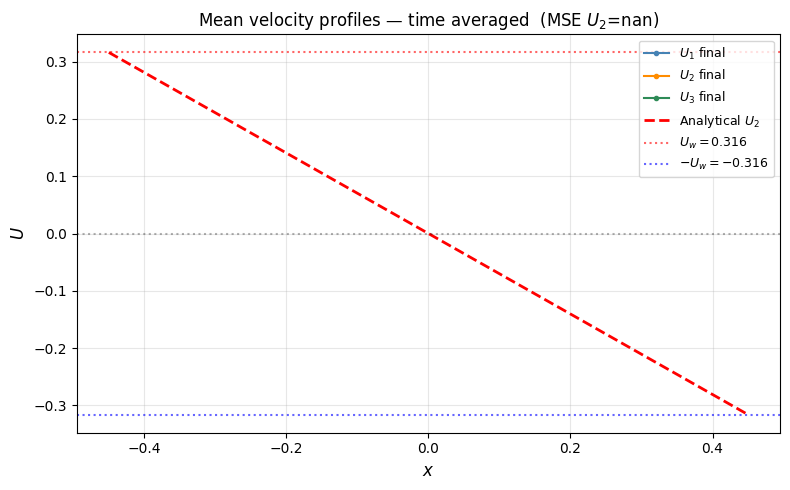

Saved: figs/presentation/velocity_profile.pdf


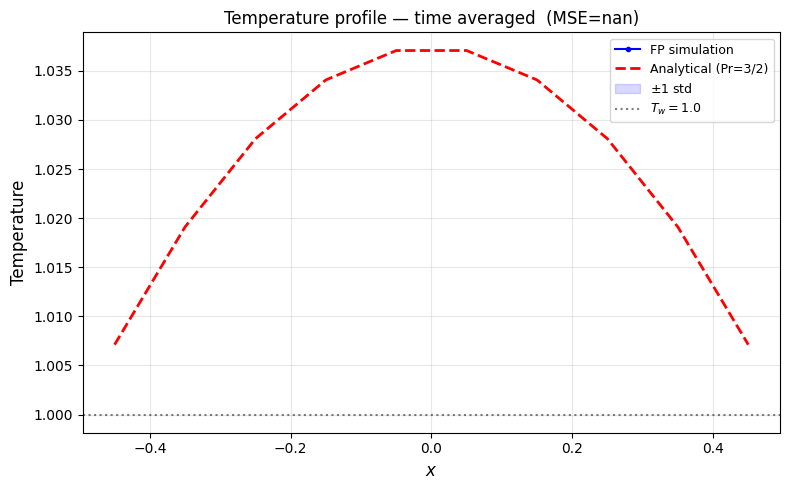

Saved: figs/presentation/temperature_profile.pdf
T center analytical: 1.037072
T wall   analytical: 1.007115
Delta T  analytical: 0.037072


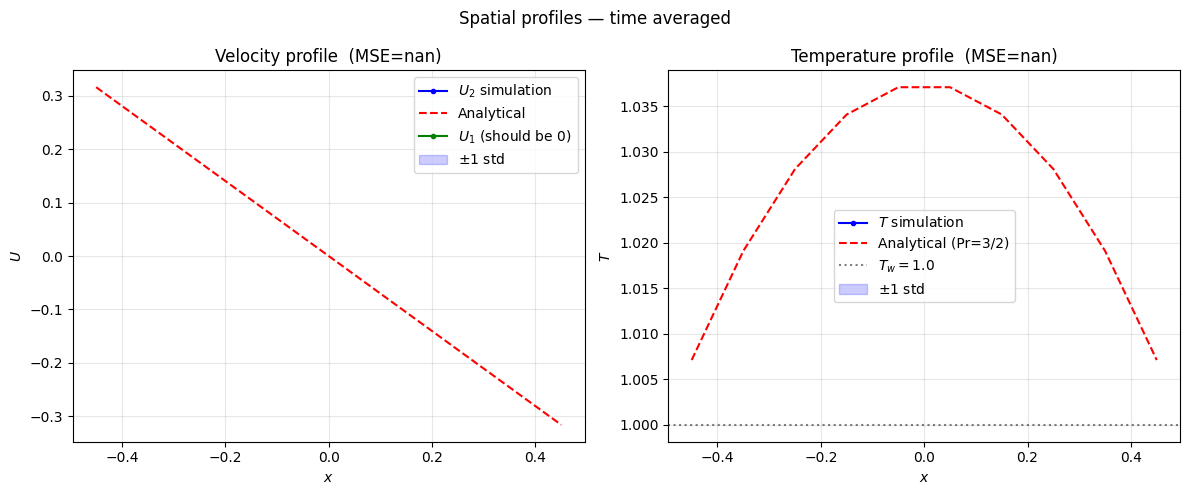

Saved: figs/profiles.pdf


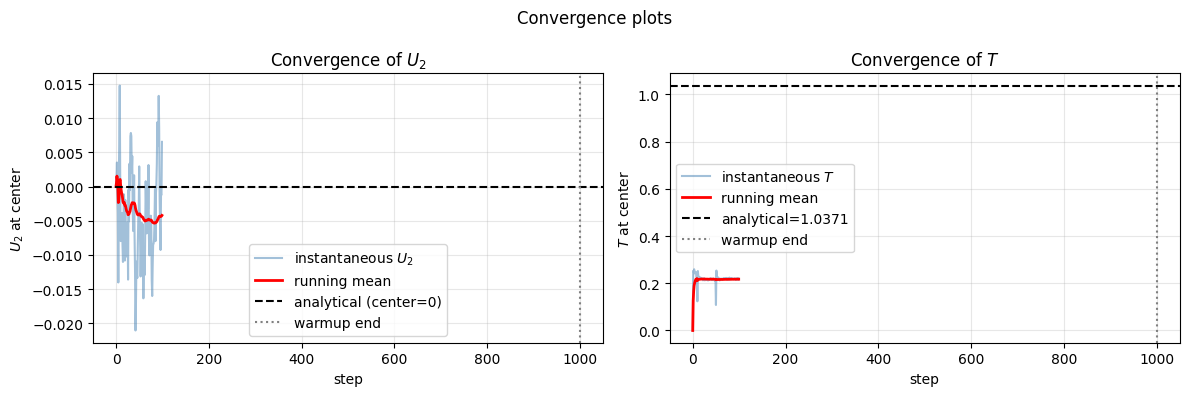

Saved: figs/convergence.pdf


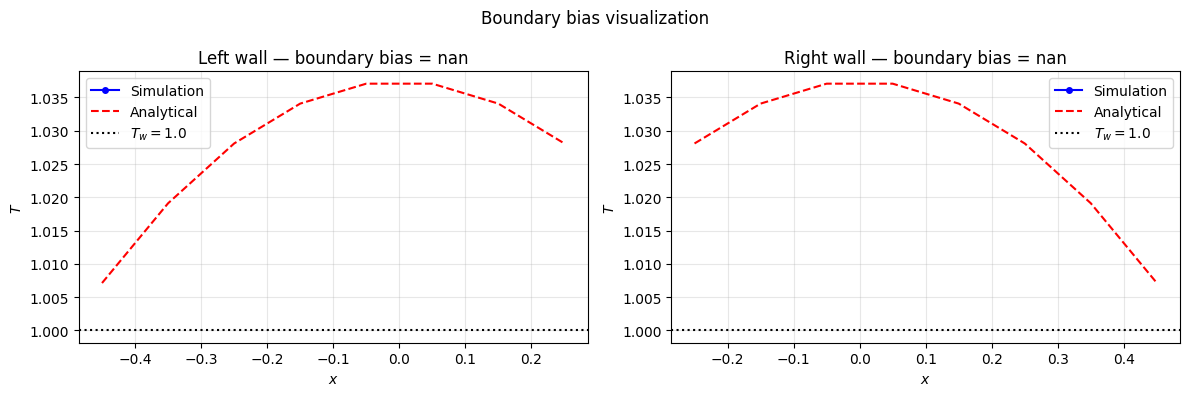

Saved: figs/boundary_bias.pdf


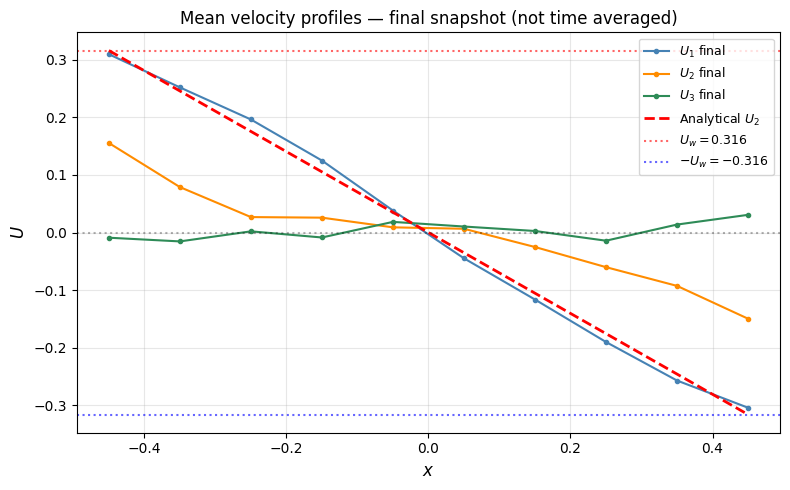

Saved: figs/velocity_final_snapshot.pdf


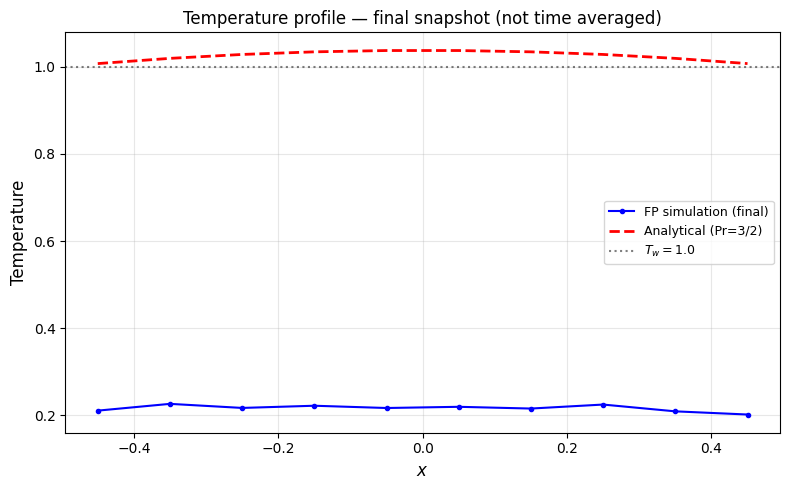

Saved: figs/temperature_final_snapshot.pdf
T center (final snapshot): 0.219600
T wall   (final snapshot): 0.210839


In [7]:
os.makedirs('figs', exist_ok=True)
os.makedirs('figs/presentation', exist_ok=True)

warmup = 1000  # ~10 tau

Pr = 3/2
U_analytical = np.linspace(Uw, -Uw, Nc)
T_analytical = Tw + (Pr/2) * (Uw**2/2) * (1 - 4*x_grid**2/L**2)

U_avg = np.mean(U[warmup:], axis=0)  # (Nc, 3)
T_avg = np.mean(T[warmup:], axis=0)  # (Nc,)
U_var = np.var(U[warmup:, :, 1], axis=0)
T_var = np.var(T[warmup:], axis=0)

MSE_U2 = np.mean((U_avg[:, 1] - U_analytical)**2)
MSE_U1 = np.mean(U_avg[:, 0]**2)
MSE_T  = np.mean((T_avg - T_analytical)**2)
MAE_U2 = np.max(np.abs(U_avg[:, 1] - U_analytical))
MAE_T  = np.max(np.abs(T_avg - T_analytical))
bias_T_left  = T_avg[0]  - T_analytical[0]
bias_T_right = T_avg[-1] - T_analytical[-1]

print(f"\n{'='*50}")
print(f"{'Metric':<35} {'Value':>12}")
print(f"{'='*50}")
print(f"{'MSE U2 (streamwise)':<35} {MSE_U2:>12.6f}")
print(f"{'MSE U1 (wall-normal, ~0)':<35} {MSE_U1:>12.6f}")
print(f"{'MSE T':<35} {MSE_T:>12.6f}")
print(f"{'Max error U2':<35} {MAE_U2:>12.6f}")
print(f"{'Max error T':<35} {MAE_T:>12.6f}")
print(f"{'Boundary bias T left':<35} {bias_T_left:>12.6f}")
print(f"{'Boundary bias T right':<35} {bias_T_right:>12.6f}")
print(f"{'Mean temporal var U2':<35} {U_var.mean():>12.6f}")
print(f"{'T center (sim)':<35} {T_avg[Nc//2]:>12.6f}")
print(f"{'T center (analytical)':<35} {T_analytical[Nc//2]:>12.6f}")
print(f"{'T wall left (sim)':<35} {T_avg[0]:>12.6f}")
print(f"{'T wall right (sim)':<35} {T_avg[-1]:>12.6f}")
print(f"{'='*50}")

# ============================================================
# figs/presentation — PLOT A: U final snapshot (all 3 components)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue', 'darkorange', 'seagreen']
for i in range(3):
    ax.plot(x_grid, U_avg[:, i], 'o-', color=colors[i],
            markersize=3, label=f'$U_{i+1}$ final')
ax.fill_between(x_grid,
    U_avg[:, 1] - np.sqrt(U_var),
    U_avg[:, 1] + np.sqrt(U_var),
    alpha=0.15, color='steelblue')
ax.plot(x_grid, U_analytical, 'r--', linewidth=2, label='Analytical $U_2$')
ax.axhline(y=Uw,  color='r', linestyle=':', alpha=0.6, label=f'$U_w={Uw:.3f}$')
ax.axhline(y=-Uw, color='b', linestyle=':', alpha=0.6, label=f'$-U_w={-Uw:.3f}$')
ax.axhline(y=0,   color='k', linestyle=':', alpha=0.3)
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$U$', fontsize=12)
ax.set_title(f'Mean velocity profiles — time averaged  (MSE $U_2$={MSE_U2:.2e})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/presentation/velocity_profile.pdf', dpi=150, bbox_inches='tight')
plt.savefig('figs/presentation/velocity_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figs/presentation/velocity_profile.pdf")

# ============================================================
# figs/presentation — PLOT B: T profile with analytical
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_grid, T_avg, 'b-o', markersize=3, label='FP simulation')
ax.plot(x_grid, T_analytical, 'r--', linewidth=2, label='Analytical (Pr=3/2)')
ax.fill_between(x_grid,
    T_avg - np.sqrt(T_var),
    T_avg + np.sqrt(T_var),
    alpha=0.15, color='blue', label='$\pm 1$ std')
ax.axhline(y=Tw, color='k', linestyle=':', alpha=0.5, label=f'$T_w={Tw}$')
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('Temperature', fontsize=12)
ax.set_title(f'Temperature profile — time averaged  (MSE={MSE_T:.2e})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/presentation/temperature_profile.pdf', dpi=150, bbox_inches='tight')
plt.savefig('figs/presentation/temperature_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: figs/presentation/temperature_profile.pdf")
print(f"T center analytical: {T_analytical[Nc//2]:.6f}")
print(f"T wall   analytical: {T_analytical[0]:.6f}")
print(f"Delta T  analytical: {T_analytical[Nc//2] - Tw:.6f}")

# ============================================================
# figs/ — PLOT 1: Profiles side by side (time averaged)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x_grid, U_avg[:, 1], 'b-o', markersize=3, label='$U_2$ simulation')
axes[0].plot(x_grid, U_analytical, 'r--', label='Analytical')
axes[0].plot(x_grid, U_avg[:, 0], 'g-o', markersize=3, label='$U_1$ (should be 0)')
axes[0].fill_between(x_grid,
    U_avg[:, 1] - np.sqrt(U_var),
    U_avg[:, 1] + np.sqrt(U_var),
    alpha=0.2, color='blue', label='$\pm 1$ std')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$U$')
axes[0].set_title(f'Velocity profile  (MSE={MSE_U2:.2e})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_grid, T_avg, 'b-o', markersize=3, label='$T$ simulation')
axes[1].plot(x_grid, T_analytical, 'r--', label='Analytical (Pr=3/2)')
axes[1].axhline(y=Tw, color='k', linestyle=':', alpha=0.5, label='$T_w=1.0$')
axes[1].fill_between(x_grid,
    T_avg - np.sqrt(T_var),
    T_avg + np.sqrt(T_var),
    alpha=0.2, color='blue', label='$\pm 1$ std')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$T$')
axes[1].set_title(f'Temperature profile  (MSE={MSE_T:.2e})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Spatial profiles — time averaged')
plt.tight_layout()
plt.savefig('figs/profiles.pdf', dpi=150, bbox_inches='tight')
plt.savefig('figs/profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figs/profiles.pdf")

# ============================================================
# figs/ — PLOT 2: Convergence over time
# ============================================================
center = Nc // 2
running_mean_U = np.cumsum(U[:, center, 1]) / np.arange(1, Nsteps+1)
running_mean_T = np.cumsum(T[:, center])    / np.arange(1, Nsteps+1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(U[:, center, 1], alpha=0.5, color='steelblue', label='instantaneous $U_2$')
axes[0].plot(running_mean_U, 'r-', linewidth=2, label='running mean')
axes[0].axhline(y=0.0, color='k', linestyle='--', label='analytical (center=0)')
axes[0].axvline(x=warmup, color='gray', linestyle=':', label='warmup end')
axes[0].set_xlabel('step')
axes[0].set_ylabel('$U_2$ at center')
axes[0].set_title('Convergence of $U_2$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(T[:, center], alpha=0.5, color='steelblue', label='instantaneous $T$')
axes[1].plot(running_mean_T, 'r-', linewidth=2, label='running mean')
axes[1].axhline(y=T_analytical[center], color='k', linestyle='--',
                label=f'analytical={T_analytical[center]:.4f}')
axes[1].axvline(x=warmup, color='gray', linestyle=':', label='warmup end')
axes[1].set_xlabel('step')
axes[1].set_ylabel('$T$ at center')
axes[1].set_title('Convergence of $T$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Convergence plots')
plt.tight_layout()
plt.savefig('figs/convergence.pdf', dpi=150, bbox_inches='tight')
plt.savefig('figs/convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figs/convergence.pdf")

# ============================================================
# figs/ — PLOT 3: Boundary bias zoom
# ============================================================
n_wall = 8

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_grid[:n_wall], T_avg[:n_wall], 'b-o', markersize=4, label='Simulation')
axes[0].plot(x_grid[:n_wall], T_analytical[:n_wall], 'r--', label='Analytical')
axes[0].axhline(y=Tw, color='k', linestyle=':', label='$T_w=1.0$')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$T$')
axes[0].set_title(f'Left wall — boundary bias = {bias_T_left:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_grid[-n_wall:], T_avg[-n_wall:], 'b-o', markersize=4, label='Simulation')
axes[1].plot(x_grid[-n_wall:], T_analytical[-n_wall:], 'r--', label='Analytical')
axes[1].axhline(y=Tw, color='k', linestyle=':', label='$T_w=1.0$')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$T$')
axes[1].set_title(f'Right wall — boundary bias = {bias_T_right:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Boundary bias visualization')
plt.tight_layout()
plt.savefig('figs/boundary_bias.pdf', dpi=150, bbox_inches='tight')
plt.savefig('figs/boundary_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figs/boundary_bias.pdf")

# ============================================================
# figs/ — PLOT 4: Final snapshot velocity (not time averaged)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue', 'darkorange', 'seagreen']
for i in range(3):
    ax.plot(x_grid, U[-1, :, i], 'o-', color=colors[i],
            markersize=3, label=f'$U_{i+1}$ final')
ax.plot(x_grid, U_analytical, 'r--', linewidth=2, label='Analytical $U_2$')
ax.axhline(y=Uw,  color='r', linestyle=':', alpha=0.6, label=f'$U_w={Uw:.3f}$')
ax.axhline(y=-Uw, color='b', linestyle=':', alpha=0.6, label=f'$-U_w={-Uw:.3f}$')
ax.axhline(y=0,   color='k', linestyle=':', alpha=0.3)
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$U$', fontsize=12)
ax.set_title('Mean velocity profiles — final snapshot (not time averaged)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/velocity_final_snapshot.pdf', dpi=150, bbox_inches='tight')
plt.savefig('figs/velocity_final_snapshot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figs/velocity_final_snapshot.pdf")

# ============================================================
# figs/ — PLOT 5: Final snapshot temperature (not time averaged)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_grid, T[-1, :], 'b-o', markersize=3, label='FP simulation (final)')
ax.plot(x_grid, T_analytical, 'r--', linewidth=2, label='Analytical (Pr=3/2)')
ax.axhline(y=Tw, color='k', linestyle=':', alpha=0.5, label=f'$T_w={Tw}$')
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('Temperature', fontsize=12)
ax.set_title('Temperature profile — final snapshot (not time averaged)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/temperature_final_snapshot.pdf', dpi=150, bbox_inches='tight')
plt.savefig('figs/temperature_final_snapshot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: figs/temperature_final_snapshot.pdf")
print(f"T center (final snapshot): {T[-1, Nc//2]:.6f}")
print(f"T wall   (final snapshot): {T[-1, 0]:.6f}")